# Plotting the Datasets

## Imports

In [1]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd


## Artificial Datasets

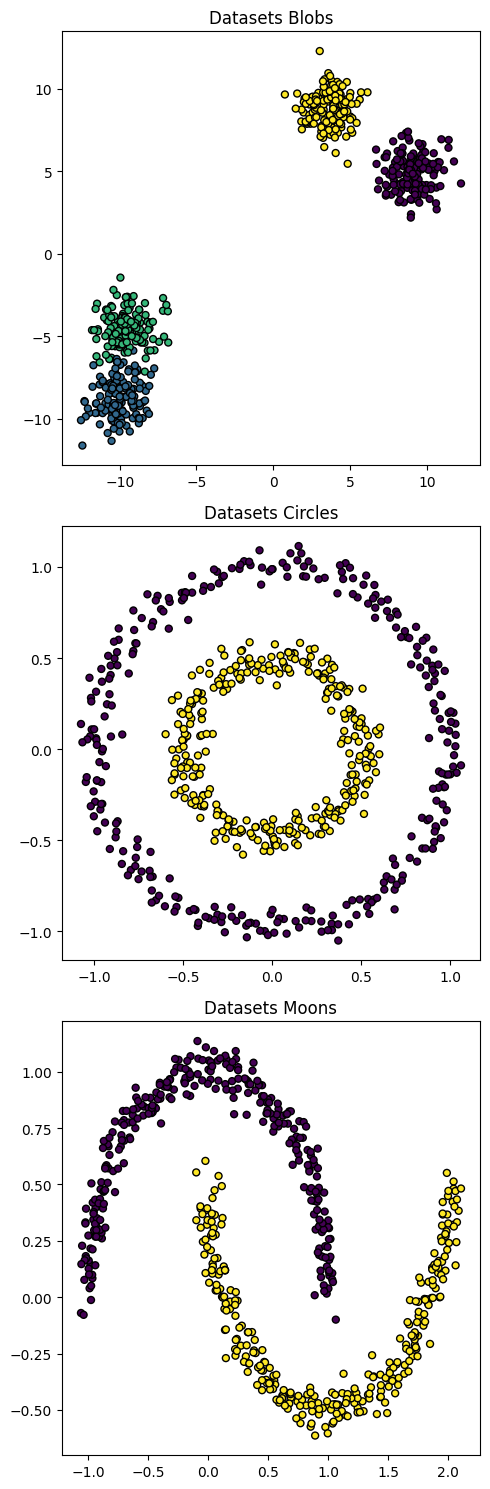

In [3]:
X_blobs,y_blobs=make_blobs(n_samples=600, n_features=2, centers=4)
X_circles, y_circles = make_circles(n_samples=600,random_state=42, factor=0.5, noise=0.05)
X_moons, y_moons = make_moons(n_samples=600,random_state=42, noise=0.05)

plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig, ax = plt.subplots(3,1,figsize=(5,15))


ax[0].title.set_text("Datasets Blobs")
ax[0].scatter(X_blobs[:, 0], X_blobs[:, 1], marker="o", s=25, c=y_blobs, edgecolor="k")

ax[1].title.set_text("Datasets Circles")
ax[1].scatter(X_circles[:, 0], X_circles[:, 1], marker="o", s=25, c=y_circles, edgecolor="k")

ax[2].title.set_text("Datasets Moons")
ax[2].scatter(X_moons[:, 0], X_moons[:, 1], marker="o", s=25, c=y_moons, edgecolor="k")

plt.savefig("All_Artificial_Datasets.svg", dpi=3000)
plt.show()

## Boxplot Blobs

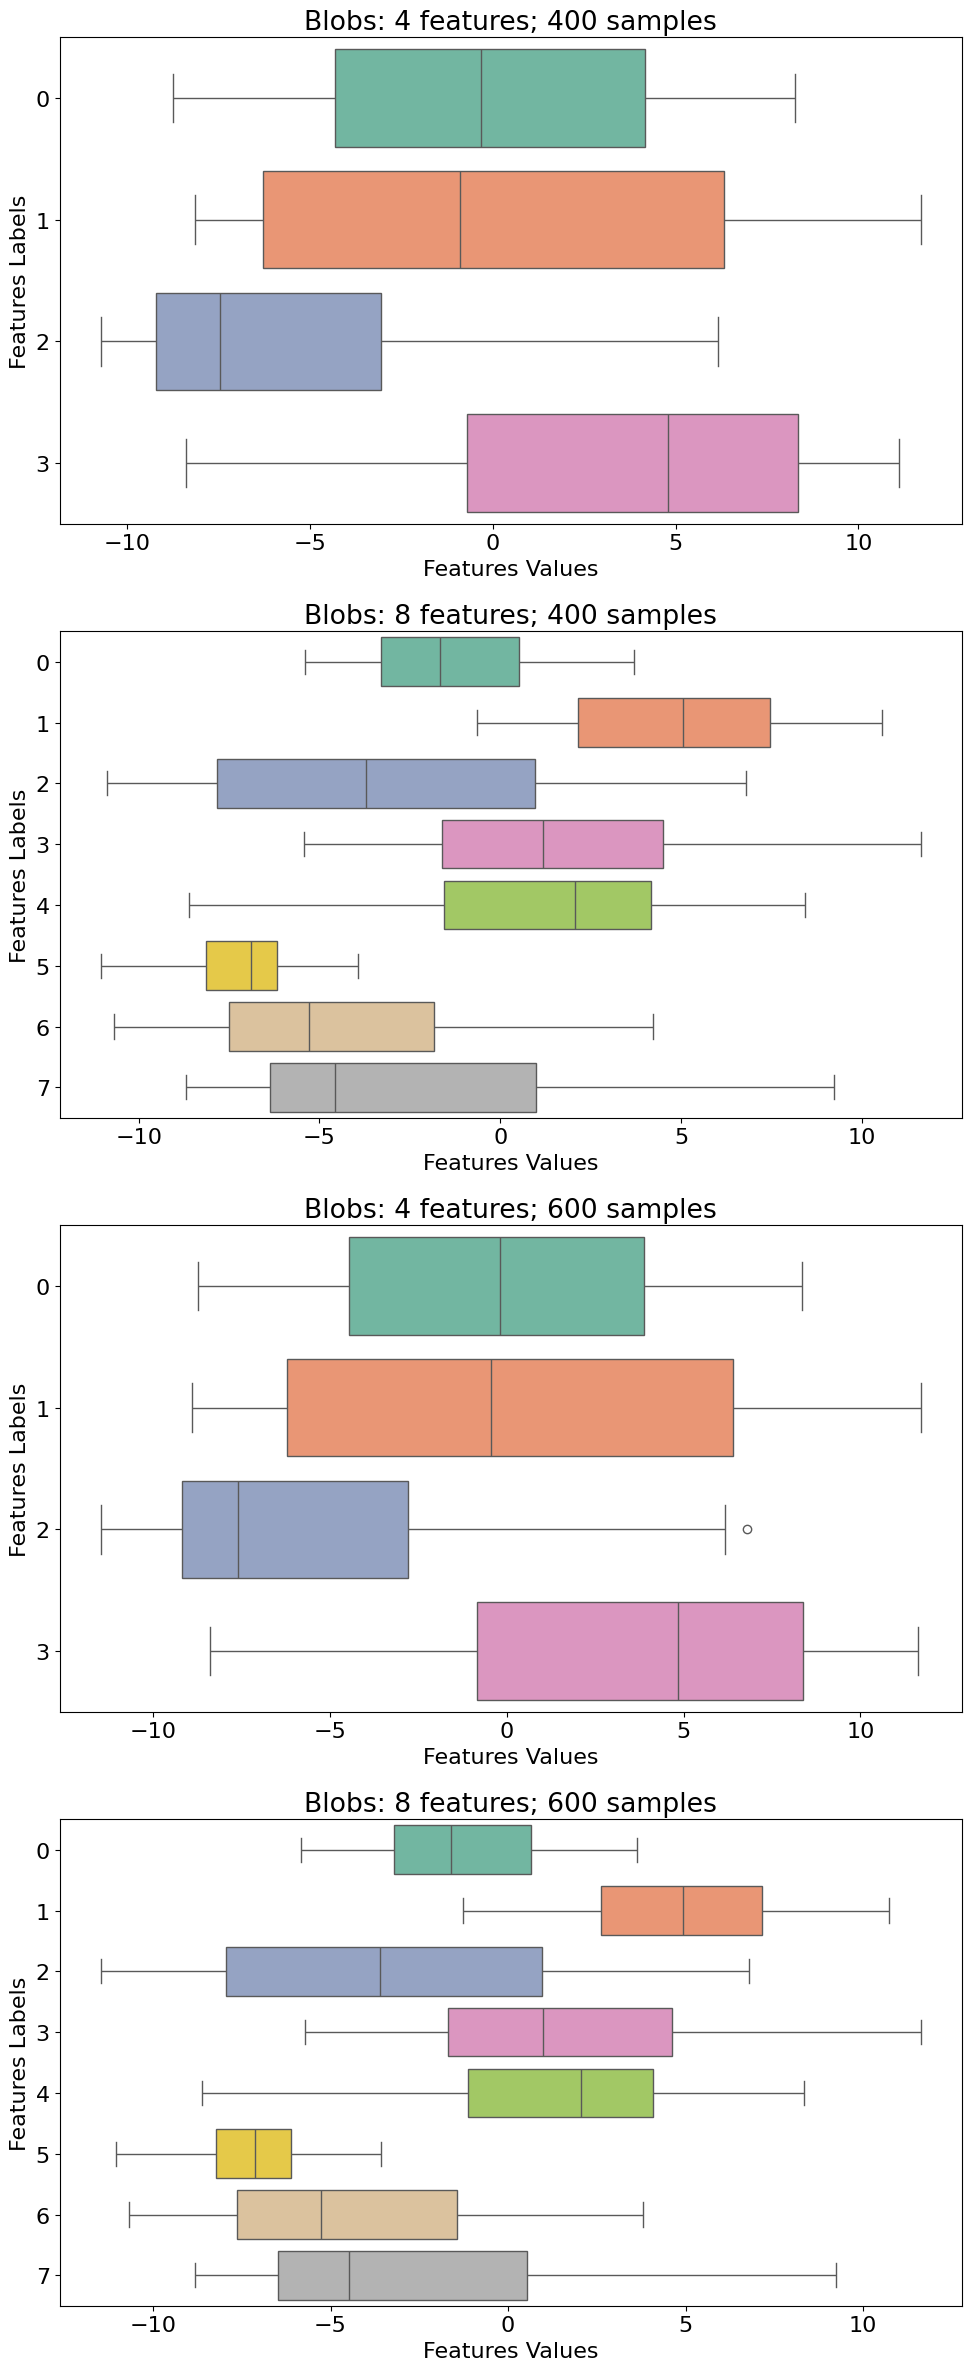

In [31]:
contador=0
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'figure.autolayout': True})
fig, ax = plt.subplots(4,1,figsize=(10,24))

def generate_blobs(n_samples, n_features, n_centers,normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_centers, random_state=42,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

N_SAMPLES_LIST=[400,600]
N_FEATURES_LIST=[4,8]
for i in range(len(N_SAMPLES_LIST)):
    for j in range(len(N_FEATURES_LIST)):
        """Creating a dataset with different settings"""
        X_blobs,y_blobs=generate_blobs(N_SAMPLES_LIST[i], N_FEATURES_LIST[j], n_centers=4, normalize_col=False, normalize_lin=False)

        """Plotting the boxplot of the normalized datasets"""
        ax[contador].title.set_text(f"Blobs: {N_FEATURES_LIST[j]} features; {N_SAMPLES_LIST[i]} samples")
        sns.boxplot(X_blobs, palette="Set2",ax=ax[contador], orient='h')
        ax[contador].set_xlabel('Features Values')
        ax[contador].set_ylabel('Features Labels')
        contador+=1

plt.savefig('All_Datasets_Boxplot_Blobs.svg', dpi=3000)

## Boxplot Circles

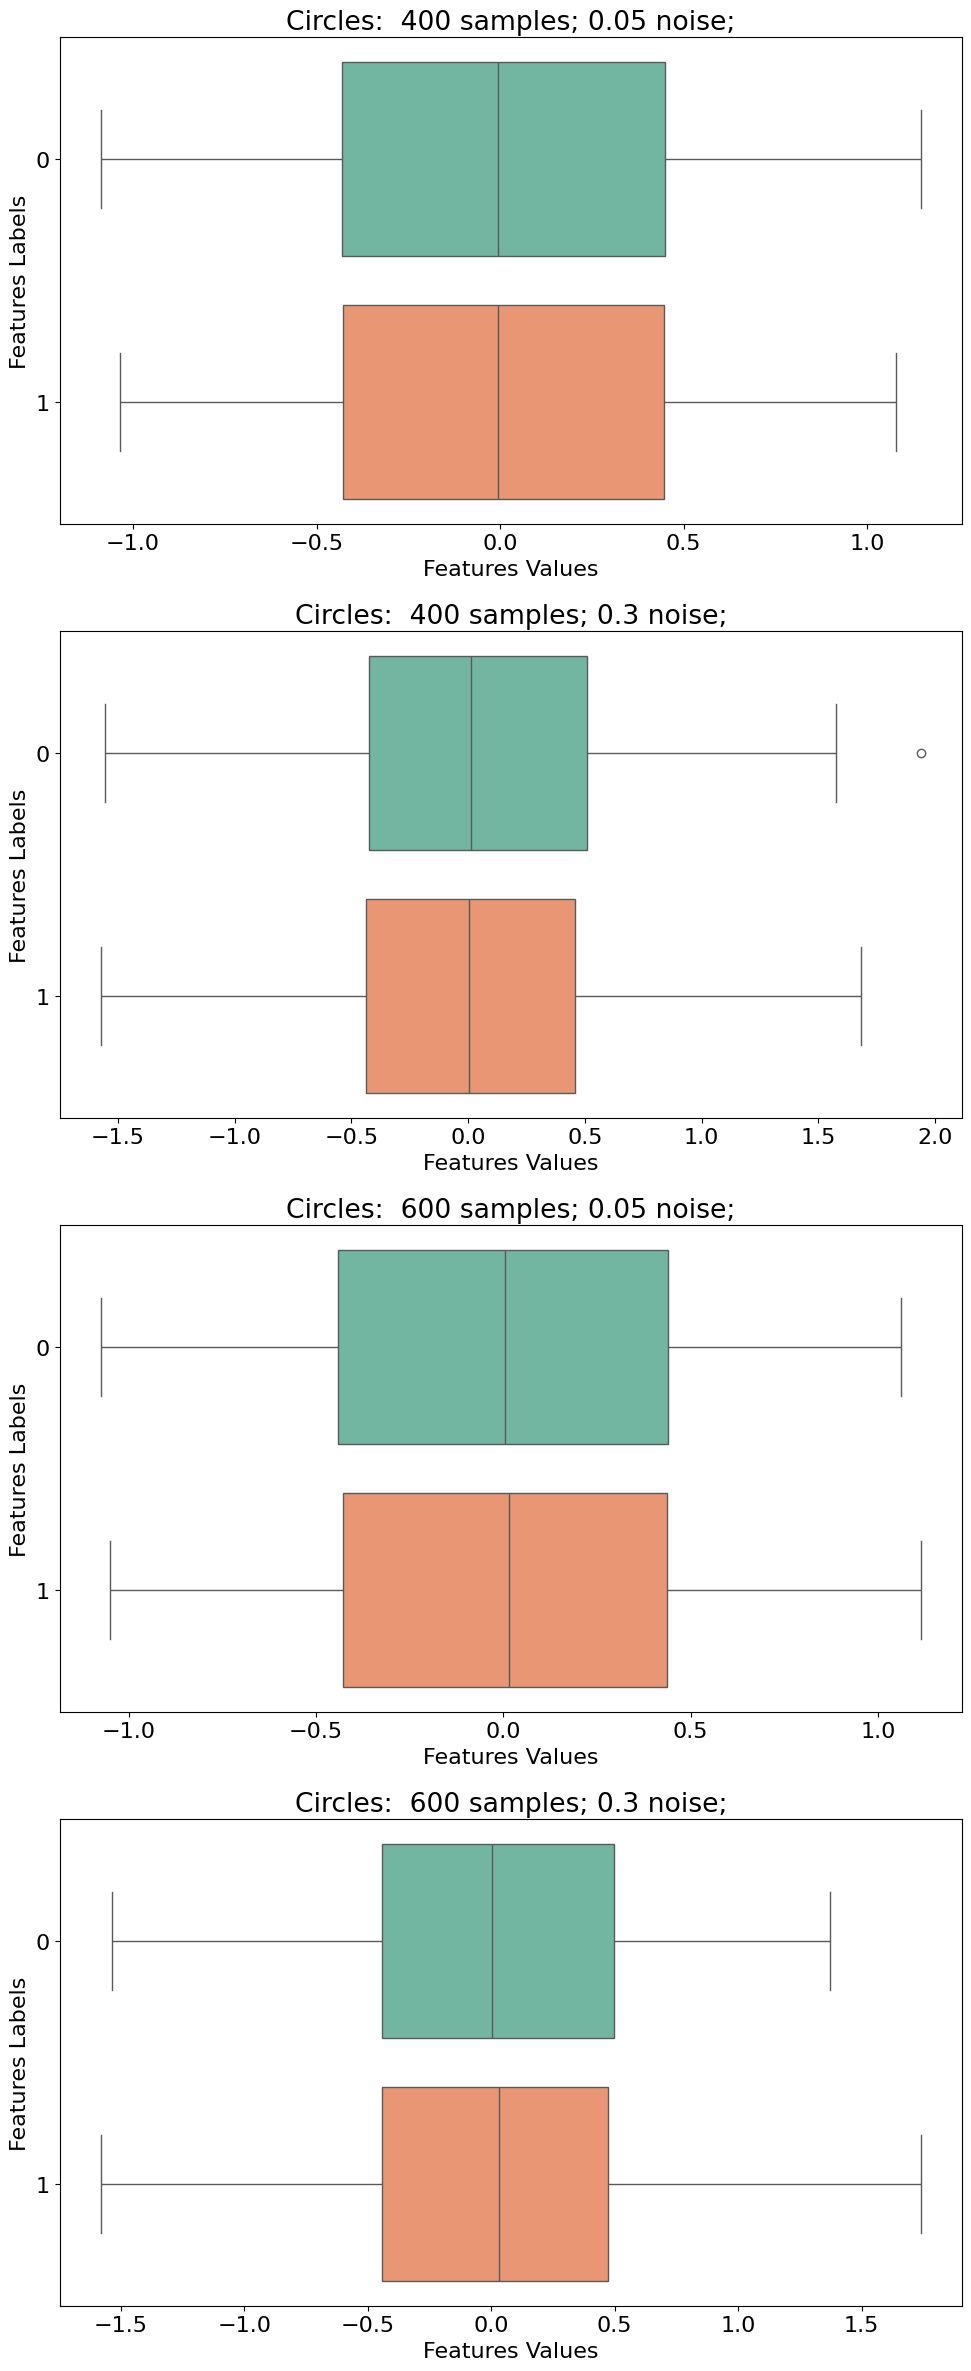

In [39]:
contador=0
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'figure.autolayout': True})
fig, ax = plt.subplots(4,1,figsize=(10,24))

def generate_circles(n_samples,noise,normalize_col=False, normalize_lin=False):
  X, y = make_circles(n_samples=n_samples, random_state=42, factor=0.5, noise=noise)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y


N_SAMPLES_LIST=[400,600]
NOISE_LIST=[0.05,0.3]
for i in range(len(N_SAMPLES_LIST)):
    for j in range(len(NOISE_LIST)):
        """Creating a dataset with different settings"""
        X_circles,y_circles=generate_circles(N_SAMPLES_LIST[i], NOISE_LIST[j], normalize_col=False, normalize_lin=False)

        """Plotting the boxplot of the normalized datasets"""
        ax[contador].title.set_text(f"Circles:  {N_SAMPLES_LIST[i]} samples; {NOISE_LIST[j]} noise;")
        sns.boxplot(X_circles, palette="Set2",ax=ax[contador], orient='h')
        ax[contador].set_xlabel('Features Values')
        ax[contador].set_ylabel('Features Labels')
        contador+=1

plt.savefig('All_Datasets_Boxplot_Circles.svg', dpi=3000)

## Boxplot Moons

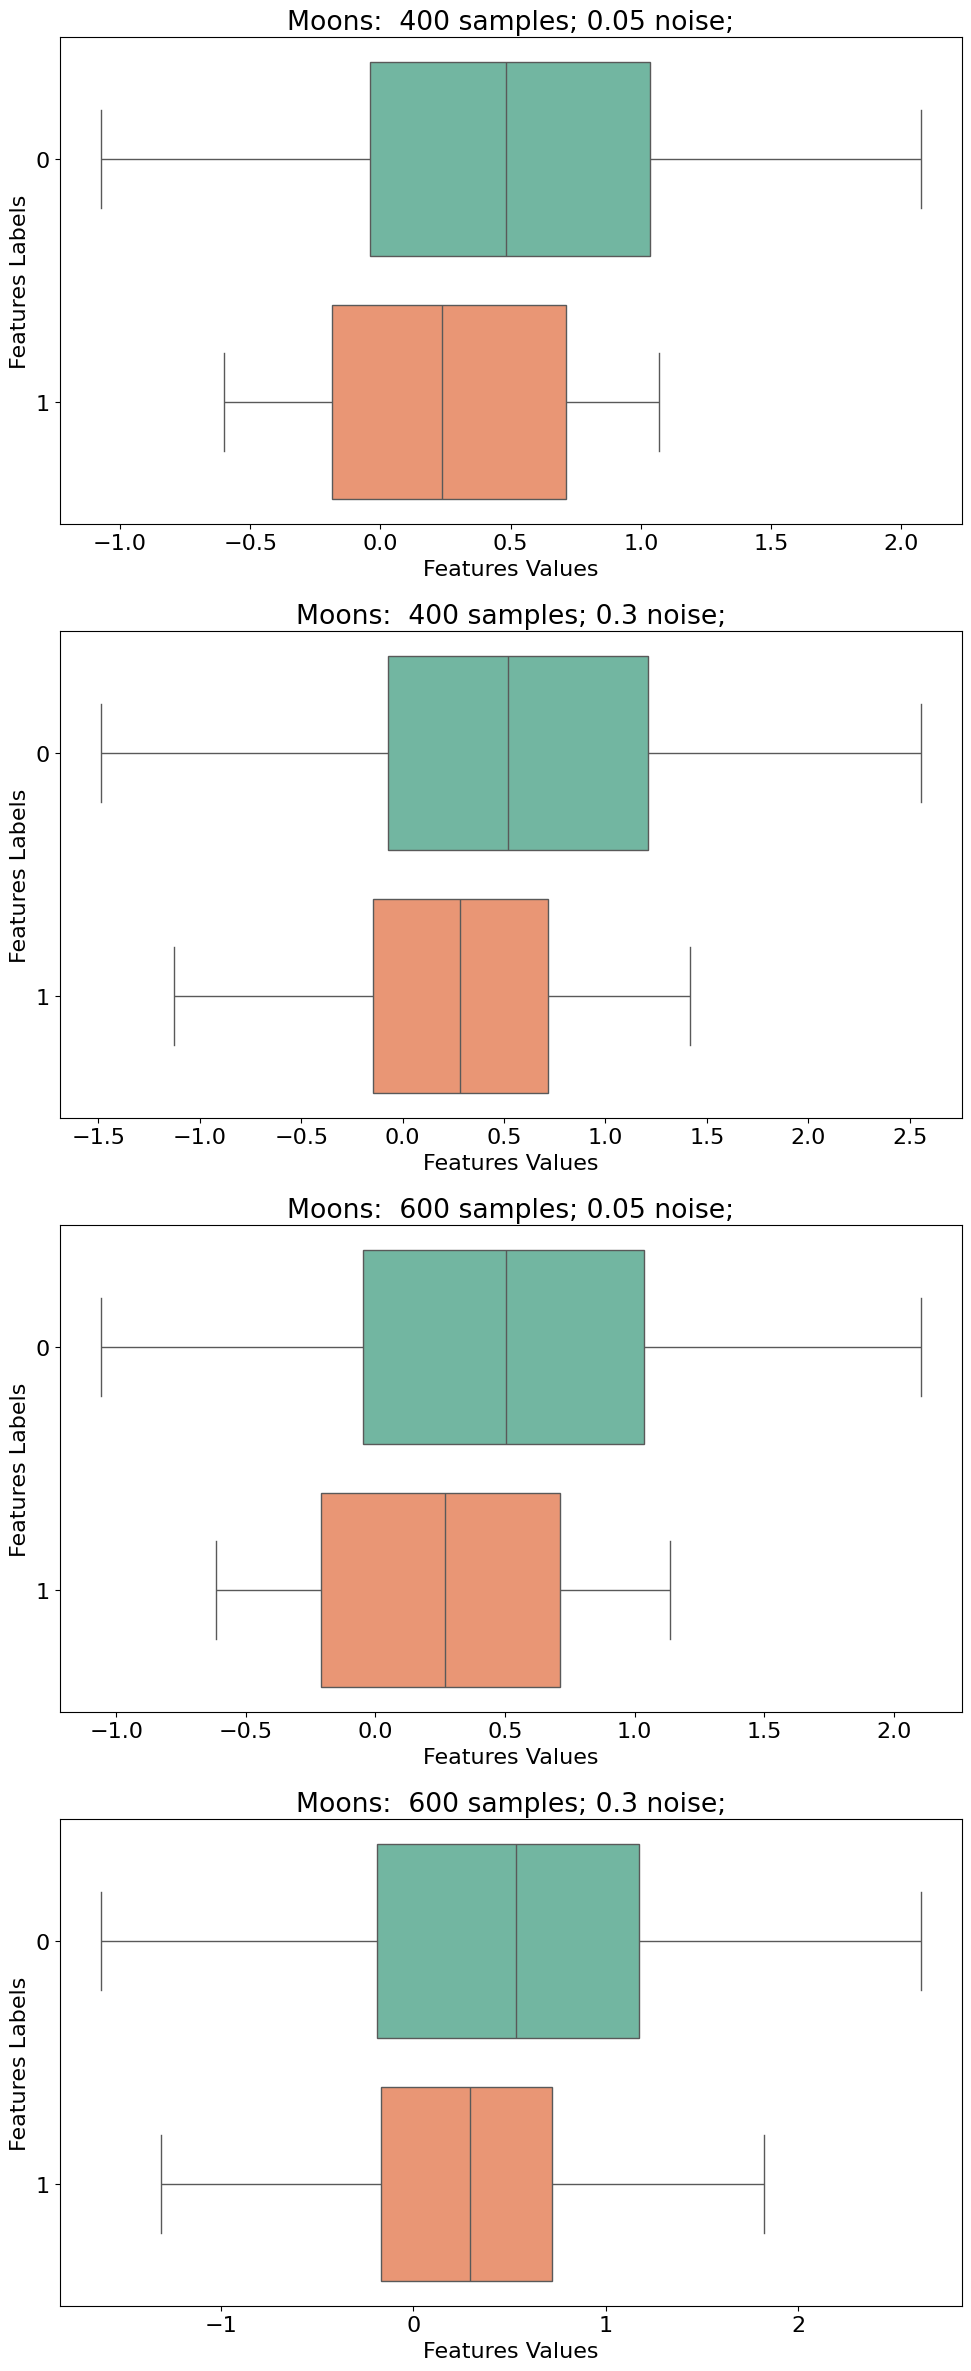

In [41]:
contador=0
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'figure.autolayout': True})
fig, ax = plt.subplots(4,1,figsize=(10,24))

def generate_moons(n_samples,noise,normalize_col=False, normalize_lin=False):
  X, y = make_moons(n_samples=n_samples, random_state=42, noise=noise)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y


N_SAMPLES_LIST=[400,600]
NOISE_LIST=[0.05,0.3]
for i in range(len(N_SAMPLES_LIST)):
    for j in range(len(NOISE_LIST)):
        """Creating a dataset with different settings"""
        X_moons,y_moons=generate_moons(N_SAMPLES_LIST[i], NOISE_LIST[j], normalize_col=False, normalize_lin=False)

        """Plotting the boxplot of the normalized datasets"""
        ax[contador].title.set_text(f"Moons:  {N_SAMPLES_LIST[i]} samples; {NOISE_LIST[j]} noise;")
        sns.boxplot(X_moons, palette="Set2",ax=ax[contador], orient='h')
        ax[contador].set_xlabel('Features Values')
        ax[contador].set_ylabel('Features Labels')
        contador+=1

plt.savefig('All_Datasets_Boxplot_Moons.svg', dpi=3000)

## Boxplot BCWD

In [15]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normaliza a coluna entre [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        #data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data

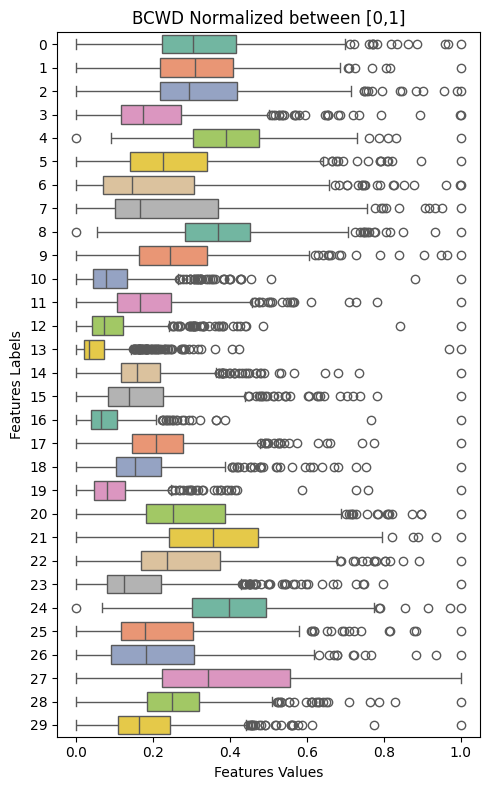

In [27]:
#Gerando o dataset
bc = fetch_ucirepo(id=17)
# data (as pandas dataframes)
X_bc = bc.data.features 
X_bc = X_bc.values

scaler = MinMaxScaler() #Normaliza a coluna entre [0,1]
scaler.fit(X_bc)
X_bc = scaler.transform(X_bc)

y_bc = bc.data.targets
y_bc = y_bc.values

plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig, ax = plt.subplots(figsize=(5,8))
ax.title.set_text("BCWD Normalized between [0,1]")
sns.boxplot(X_bc, palette="Set2",ax=ax,orient="h")
ax.set_xlabel('Features Values')
ax.set_ylabel('Features Labels')
plt.savefig('All_Datasets_Boxplot_BC.svg', dpi=3000)

## Boxplot Iris

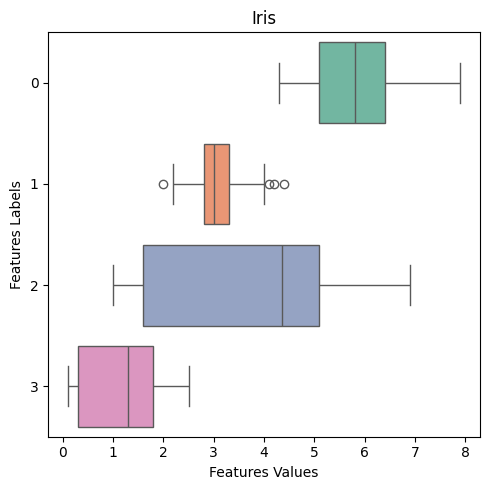

In [29]:
iris = fetch_ucirepo(id=53)
# data (as pandas dataframes)
X_iris = iris.data.features 
X_iris = X_iris.values

y_iris = iris.data.targets
y_iris = y_iris.values

plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
fig, ax = plt.subplots(figsize=(5,5))
ax.title.set_text("Iris") # Normalized between [0,1]")
sns.boxplot(X_iris, palette="Set2",ax=ax,orient="h")
ax.set_xlabel('Features Values')
ax.set_ylabel('Features Labels')
plt.savefig('All_Datasets_Boxplot_Iris.svg', dpi=3000)